           STUDENT PERFORMANCE DATASET
Shape: (500, 6)

   study_hours  attendance_pct  prev_score  sleep_hours  extracurricular  \
0     4.370861       84.908086   51.107976     7.114491                1   
1     9.556429       76.804818   72.514057     6.875091                0   
2     7.587945       65.476381   92.376750     4.153852                0   
3     6.387926       90.689751   83.933493     6.047487                0   
4     2.404168       84.236559   88.393669     6.281174                1   

   final_grade  
0    62.191854  
1    73.940500  
2    66.619144  
3    74.211786  
4    50.848049  

── Descriptive Statistics ──────────────────────────────
       study_hours  attendance_pct  prev_score  sleep_hours  extracurricular  \
count       500.00          500.00      500.00       500.00           500.00   
mean          5.49           74.10       71.05         6.98             0.52   
std           2.69           14.27       17.83         1.72             0.50   
min    

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

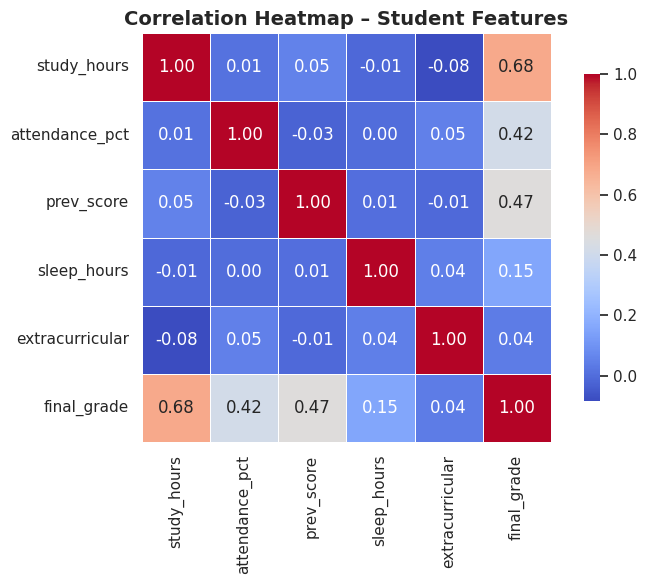

In [ ]:
# ============================================================
# Task 3: Predict Student Performance using Multiple Regression
# ============================================================
# Libraries used: numpy, pandas, matplotlib, seaborn, sklearn
# Run this in Google Colab or Jupyter Notebook

# ── 1. Import Libraries ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Makes plots look nicer
sns.set_theme(style="whitegrid", palette="muted")
np.random.seed(42)          # reproducibility

# ── 2. Generate Synthetic Dataset (500 students) ─────────────
n = 500

study_hours      = np.random.uniform(1, 10, n)          # hours per day
attendance_pct   = np.random.uniform(50, 100, n)        # % attendance
prev_score       = np.random.uniform(40, 100, n)        # previous exam score
sleep_hours      = np.random.uniform(4, 10, n)          # hours of sleep per night
extracurricular  = np.random.randint(0, 2, n)           # 0 = No, 1 = Yes

# Build final_grade as a realistic weighted combination + noise
# Higher study hours, attendance, prev_score, sleep → higher grade
# Extracurricular has a small positive effect
noise = np.random.normal(0, 4, n)

final_grade = (
    2.5  * study_hours      +   # strong positive effect
    0.3  * attendance_pct   +   # moderate positive effect
    0.25 * prev_score       +   # moderate positive effect
    1.0  * sleep_hours      +   # mild positive effect
    2.0  * extracurricular  +   # small positive effect
    noise
)

# Clip grades to a realistic 0–100 range
final_grade = np.clip(final_grade, 0, 100)

# Assemble into a DataFrame
df = pd.DataFrame({
    "study_hours":     study_hours,
    "attendance_pct":  attendance_pct,
    "prev_score":      prev_score,
    "sleep_hours":     sleep_hours,
    "extracurricular": extracurricular,
    "final_grade":     final_grade
})

print("=" * 55)
print("           STUDENT PERFORMANCE DATASET")
print("=" * 55)
print(f"Shape: {df.shape}\n")
print(df.head())

# ── 3. Exploratory Data Analysis (EDA) ───────────────────────
print("\n── Descriptive Statistics ──────────────────────────────")
print(df.describe().round(2))

print("\n── Missing Values ──────────────────────────────────────")
print(df.isnull().sum())
# No missing values since we generated the data, but good practice to check

print("\n── Correlation Matrix ──────────────────────────────────")
corr = df.corr()
print(corr.round(2))

# ── 4. Visualisations ────────────────────────────────────────

# --- 4a. Heatmap of correlations ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,          # show numbers inside cells
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap – Student Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt